In [2]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import rasterio

from aerial_detect.classes import NAMES, to_index

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
RAW = ROOT / "data" / "raw"
print("Running in:", Path.cwd())
print("Labels file found:", (RAW / "xView_train.geojson").exists())
gdf = gpd.read_file(RAW / "xView_train.geojson")
print(f"{len(gdf):,} objects in {gdf['image_id'].nunique()} images")
print(list(gdf.columns))
print(gdf.crs)

Running in: /home/pw070zsy-indycar/aerial-detect
Labels file found: True
601,937 objects in 847 images
['bounds_imcoords', 'edited_by', 'cat_id', 'type_id', 'ingest_time', 'index_right', 'image_id', 'point_geom', 'feature_id', 'grid_file', 'geometry']
EPSG:4326


In [3]:
b = gdf["bounds_imcoords"].str.split(",", expand=True).astype(float)
b.columns = ["xmin", "ymin", "xmax", "ymax"]
df = pd.concat([gdf[["image_id", "type_id"]], b], axis=1)
df["w"] = df.xmax - df.xmin
df["h"] = df.ymax - df.ymin
df["cls"] = df["type_id"].astype(int).map(to_index)
df["name"] = df["cls"].map(lambda i: NAMES[i] if i >= 0 else "NOT A CLASS")
df.head()

,image_id,type_id,xmin,ymin,xmax,ymax,w,h,cls,name
0,2355.tif,73,2712.0,1145.0,2746.0,1177.0,34.0,32.0,48,Building
1,2355.tif,73,2720.0,2233.0,2760.0,2288.0,40.0,55.0,48,Building
2,2355.tif,73,2687.0,1338.0,2740.0,1399.0,53.0,61.0,48,Building
3,2355.tif,73,2691.0,1201.0,2730.0,1268.0,39.0,67.0,48,Building
4,2355.tif,73,2671.0,838.0,2714.0,869.0,43.0,31.0,48,Building


name
Building                  316795
Small Car                 211664
Truck                      12189
Bus                         6975
Cargo Truck                 5899
Vehicle Lot                 4266
Trailer                     4103
Truck w/Box                 3653
Utility Truck               3639
Passenger Vehicle           2954
Shipping container lot      2379
Cargo Car                   1851
Storage Tank                1712
Passenger Car               1631
Shipping Container          1589
Name: count, dtype: int64
Objects with no valid class: 79


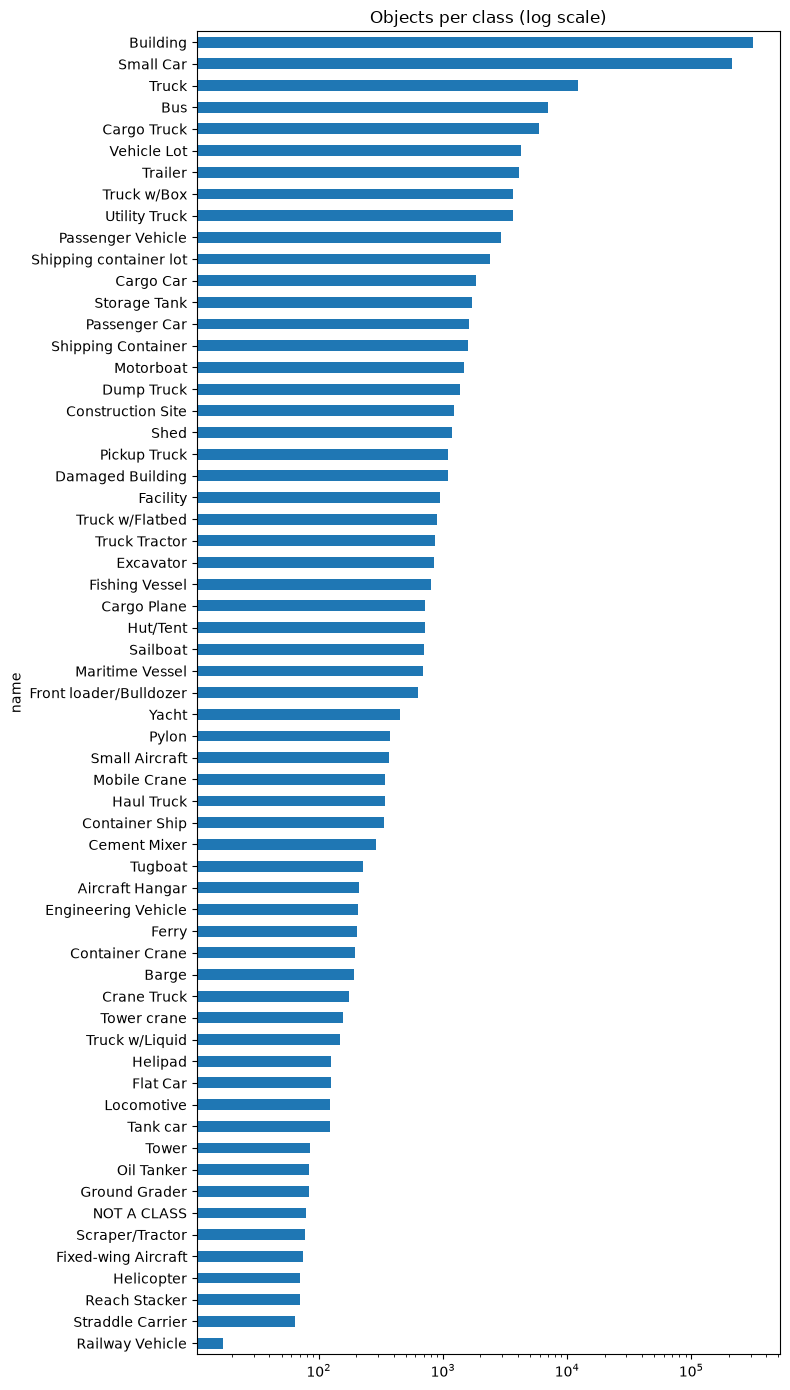

In [4]:
counts = df["name"].value_counts()
print(counts.head(15))
print("Objects with no valid class:", (df.cls < 0).sum())
counts.sort_values().plot.barh(figsize=(8, 14), logx=True, title="Objects per class (log scale)")
plt.tight_layout()

In [5]:
print(df[["w", "h"]].describe(percentiles=[0.05, 0.5, 0.95]))
print(f"Objects under 10 px on their longest side: {(df[['w', 'h']].max(axis=1) < 10).mean():.1%}")
df.groupby("name")[["w", "h"]].median().sort_values("w").tail(15)

                   w              h
count  601937.000000  601937.000000
mean       38.368165      33.489172
std        47.362145      39.503302
min         0.000000       0.000000
5%          9.000000       8.000000
50%        25.000000      23.000000
95%       101.000000      86.000000
max      3299.000000    3132.000000
Objects under 10 px on their longest side: 0.9%


,w,h
name,,
Tugboat,62.0,61.0
Passenger Car,63.0,30.0
Shipping container lot,75.0,68.0
Barge,84.5,70.5
Vehicle Lot,87.0,69.0
Container Crane,109.5,71.0
Tower crane,112.0,96.5
Cargo Plane,112.0,96.0
Facility,114.5,105.0


In [6]:
rows = []
for p in sorted((RAW / "train_images").glob("*.tif")):
    with rasterio.open(p) as src:
        rows.append(
            {
                "image_id": p.name,
                "width": src.width,
                "height": src.height,
                "bands": src.count,
                "crs": str(src.crs),
                "res": src.res[0],
            }
        )
imgs = pd.DataFrame(rows)
print(imgs[["width", "height", "bands", "res"]].describe())
print(imgs["crs"].value_counts())
print("Labelled images with no file:", sorted(set(df.image_id) - set(imgs.image_id)))

             width       height  bands           res
count   846.000000   846.000000  846.0  8.460000e+02
mean   3316.596927  2911.073286    3.0  3.150199e-06
std     498.737342   233.809282    0.0  2.515996e-07
min    2576.000000  2426.000000    3.0  2.775794e-06
25%    2976.000000  2764.000000    3.0  2.903804e-06
50%    3195.000000  2814.000000    3.0  3.249206e-06
75%    3439.000000  3152.750000    3.0  3.333566e-06
max    5121.000000  3325.000000    3.0  3.780111e-06
crs
EPSG:4326    846
Name: count, dtype: int64
Labelled images with no file: ['1395.tif']


In [7]:
m = df.merge(imgs[["image_id", "width", "height"]], on="image_id")
bad = (
    (m.w <= 0) | (m.h <= 0) | (m.xmin < 0) | (m.ymin < 0) | (m.xmax > m.width) | (m.ymax > m.height)
)
print(f"Problem boxes: {bad.sum():,} of {len(m):,} ({bad.mean():.2%})")
m[bad].head(10)

Problem boxes: 9,937 of 601,806 (1.65%)


,image_id,type_id,xmin,ymin,xmax,ymax,w,h,cls,name,width,height
0,2355.tif,73,2712.0,1145.0,2746.0,1177.0,34.0,32.0,48,Building,2739,2667
1,2355.tif,73,2720.0,2233.0,2760.0,2288.0,40.0,55.0,48,Building,2739,2667
2,2355.tif,73,2687.0,1338.0,2740.0,1399.0,53.0,61.0,48,Building,2739,2667
6,2355.tif,73,2709.0,1014.0,2747.0,1072.0,38.0,58.0,48,Building,2739,2667
9,2355.tif,73,2704.0,2123.0,2749.0,2151.0,45.0,28.0,48,Building,2739,2667
12,2355.tif,73,2703.0,2007.0,2745.0,2040.0,42.0,33.0,48,Building,2739,2667
24,2355.tif,73,2701.0,1285.0,2749.0,1337.0,48.0,52.0,48,Building,2739,2667
27,2355.tif,73,2718.0,2037.0,2752.0,2074.0,34.0,37.0,48,Building,2739,2667
31,2355.tif,73,2704.0,559.0,2761.0,624.0,57.0,65.0,48,Building,2739,2667
35,2355.tif,73,2709.0,2145.0,2745.0,2214.0,36.0,69.0,48,Building,2739,2667


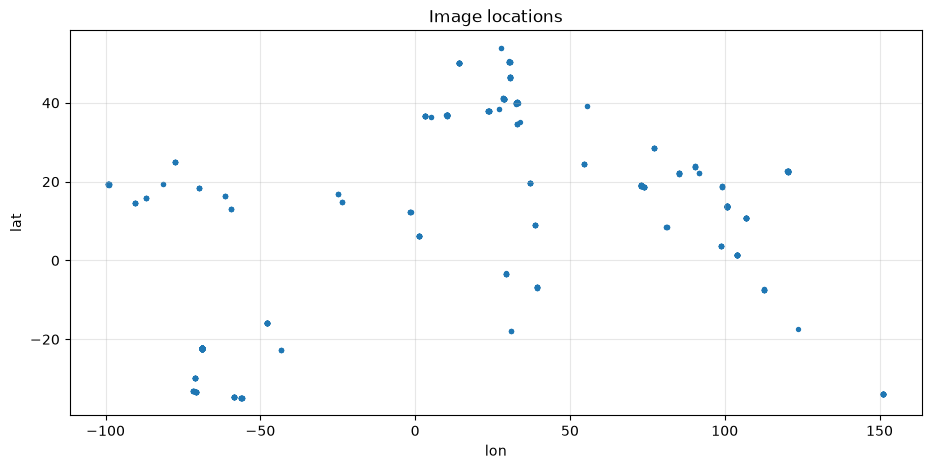

In [11]:
gb = gdf.geometry.bounds
gdf["lon"] = (gb.minx + gb.maxx) / 2
gdf["lat"] = (gb.miny + gb.maxy) / 2
loc = gdf.groupby("image_id")[["lon", "lat"]].mean()
loc.plot.scatter("lon", "lat", figsize=(11, 5), s=8, title="Image locations")
plt.grid(alpha=0.3)

In [9]:
reasons = pd.DataFrame(
    {
        "zero_or_negative_size": (m.w <= 0) | (m.h <= 0),
        "negative_coords": (m.xmin < 0) | (m.ymin < 0),
        "past_right_edge": m.xmax > m.width,
        "past_bottom_edge": m.ymax > m.height,
    }
)
print(reasons.sum())
overshoot = pd.concat([m.xmax - m.width, m.ymax - m.height]).clip(lower=0)
print(overshoot[overshoot > 0].describe())  # how far past the edge, in pixels

zero_or_negative_size       9
negative_coords          5058
past_right_edge          2615
past_bottom_edge         2368
dtype: int64
count    4983.000000
mean       51.494080
std       106.205309
min         1.000000
25%         8.000000
50%        22.000000
75%        50.000000
max      2080.000000
dtype: float64


In [10]:
huge = df[(df.w > 1000) | (df.h > 1000)]
print(len(huge))
huge["name"].value_counts().head(10)

117


name
Building                  67
Construction Site         37
Shipping container lot     5
Facility                   4
Vehicle Lot                3
Container Ship             1
Name: count, dtype: int64